# Sistema de Inferência Nebulosa (SIN) para Risco de Evasão Acadêmica

Proposta de trabalho — Ensino Superior (ver `apresentacao_sin_evasao_academica.pptx`)

Este notebook roda o SIN de ponta a ponta sobre o dataset
**Predict Students' Dropout and Academic Success** (UCI, id=697) e mostra,
seção por seção:

1. [Dataset e pré-processamento](#1.-Dataset-e-pré-processamento)
2. [SIN 1 — Bloco acadêmico](#2.-SIN-1-—-Bloco-acadêmico)
3. [SIN 2 — Bloco social/financeiro](#3.-SIN-2-—-Bloco-social/financeiro)
4. [SIN 3 — Bloco demográfico](#4.-SIN-3-—-Bloco-demográfico)
5. [SIN 4 — Sistema final](#5.-SIN-4-—-Sistema-final-(RISCO_EVASÃO))
6. [Avaliação](#6.-Avaliação)
7. [Conclusão](#7.-Conclusão)

**Ideia central** (slide 2-3): em vez de classificar rigidamente
Dropout/Graduate, o SIN retorna um **risco contínuo de evasão (0-100)**,
explicável por regras linguísticas SE-ENTÃO.


## 0. Setup

In [2]:
import sys, os
sys.path.insert(0, os.path.abspath("."))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams["figure.figsize"] = (7, 3.5)

from src import data, evaluate, pipeline
from src.blocks import academic, social, demographic, final as final_block

pd.set_option("display.max_columns", 50)


## 1. Dataset e pré-processamento

Slide 4: base *Predict Students' Dropout and Academic Success*, variável alvo
`Target` com 3 classes. Seguindo a recomendação do slide, removemos
`Enrolled` e tratamos o problema como **Dropout (1) vs Graduate (0)**.


In [3]:
raw = data.load_raw(use_cache=True)
df = data.build_features(raw)
print(f"{len(df)} alunos apos remover 'Enrolled' (de {len(raw)} originais)")
df[["nota_academica", "aprovadas", "sem_avaliacao",
    "debtor", "tuition_ok", "scholarship", "capital_educacional",
    "idade", "deslocado", "noturno", "internacional", "Target"]].head()


3630 alunos apos remover 'Enrolled' (de 4424 originais)


,nota_academica,aprovadas,sem_avaliacao,debtor,tuition_ok,scholarship,capital_educacional,idade,deslocado,noturno,internacional,Target
0,4.243333,0.0,0.0,0,1,0,1.5,20,1,0,0,Dropout
1,13.972222,6.0,0.0,0,0,0,2.5,19,1,0,0,Graduate
2,4.160000,0.0,0.0,0,0,0,1.0,19,1,0,0,Dropout
3,12.596190,5.5,0.0,0,1,0,1.0,20,1,0,0,Graduate
4,13.161111,5.5,0.0,0,1,0,1.0,45,0,1,0,Graduate


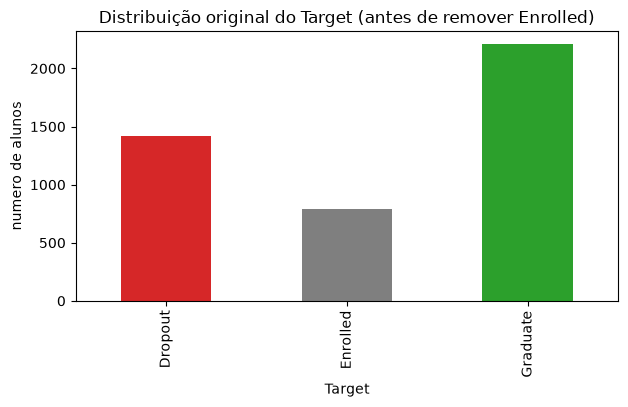

In [4]:
fig, ax = plt.subplots()
raw["Target"].value_counts().reindex(["Dropout", "Enrolled", "Graduate"]).plot.bar(
    ax=ax, color=["tab:red", "tab:gray", "tab:green"])
ax.set_title("Distribuição original do Target (antes de remover Enrolled)")
ax.set_ylabel("numero de alunos")
plt.show()


## 2. SIN 1 — Bloco acadêmico

Slide 6. Entradas: **nota** (média de admissão normalizada + notas dos 2
semestres, escala 0-20), **unidades aprovadas** e **unidades sem
avaliação**. Regras de exemplo do slide:

- SE nota é baixa E aprovadas são poucas → risco alto
- SE nota é alta E aprovadas são muitas → risco baixo
- SE disciplinas sem avaliação são muitas → risco alto


In [5]:
def plot_membership(x, curves, labels, title="Nota acadêmica"):
    order = np.argsort(x)
    fig, ax = plt.subplots()
    for curve, label in zip(curves, labels):
        ax.plot(x[order], curve[order], label=label, linewidth=2)
    ax.set_title(title)
    ax.set_ylabel("grau de pertinência")
    ax.legend()
    fig.tight_layout()
    plt.show()


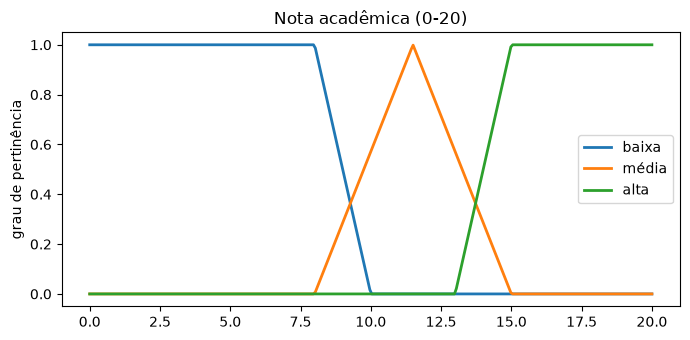

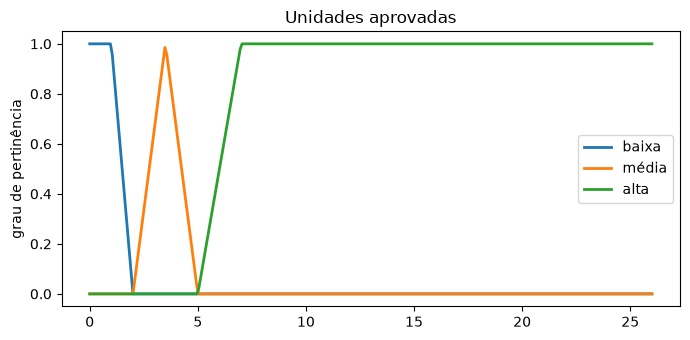

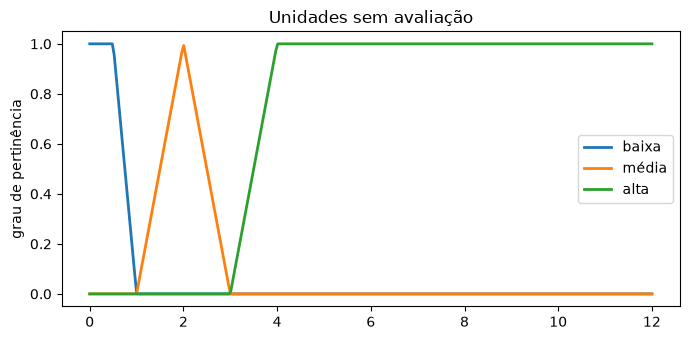

In [6]:
x_nota = np.linspace(0, 20, 300)
curves = academic.fuzzify_nota(x_nota)
plot_membership(x_nota, curves, ["baixa", "média", "alta"], "Nota acadêmica (0-20)")

x_aprov = np.linspace(0, 26, 300)
curves = academic.fuzzify_aprovadas(x_aprov)
plot_membership(x_aprov, curves, ["baixa", "média", "alta"], "Unidades aprovadas")

x_sem = np.linspace(0, 12, 300)
curves = academic.fuzzify_sem_avaliacao(x_sem)
plot_membership(x_sem, curves, ["baixa", "média", "alta"], "Unidades sem avaliação")


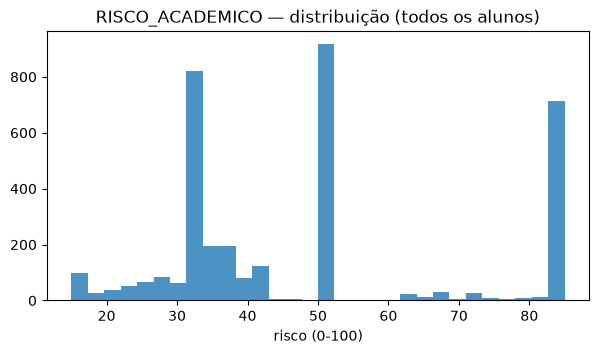

Target
Dropout     65.248252
Graduate    37.732494
Name: risco_academico, dtype: float64

In [7]:
df["risco_academico"] = academic.compute(df)

fig, ax = plt.subplots()
ax.hist(df["risco_academico"], bins=30, color="tab:blue", alpha=0.8)
ax.set_title("RISCO_ACADEMICO — distribuição (todos os alunos)")
ax.set_xlabel("risco (0-100)")
plt.show()

df.groupby("Target")["risco_academico"].mean()


## 3. SIN 2 — Bloco social/financeiro

Slide 7. Entradas: `Debtor`, `Tuition fees up to date`, `Scholarship holder`
(binárias, entram como grau de pertinência 0/1) e o **capital educacional**
da família (média da escolaridade dos pais, mapeada para escala ordinal
0-3 — ver `_QUALIFICATION_LEVEL` em `src/data.py`). Regras de exemplo:

- SE é devedor E mensalidade não está em dia → risco alto
- SE possui bolsa E mensalidade está em dia → risco baixo
- SE não possui bolsa E possui dívida → risco médio/alto


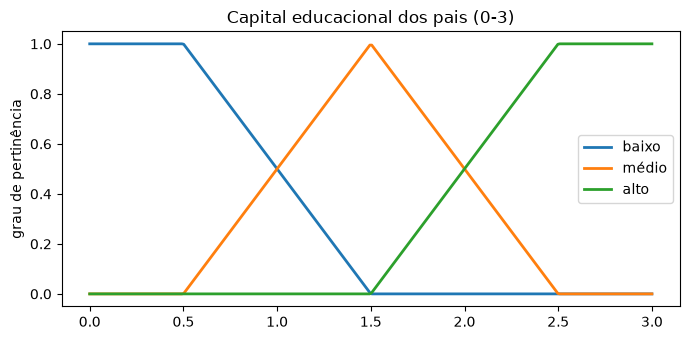

In [8]:
x_cap = np.linspace(0, 3, 300)
curves = social.fuzzify_capital(x_cap)
plot_membership(x_cap, curves, ["baixo", "médio", "alto"], "Capital educacional dos pais (0-3)")


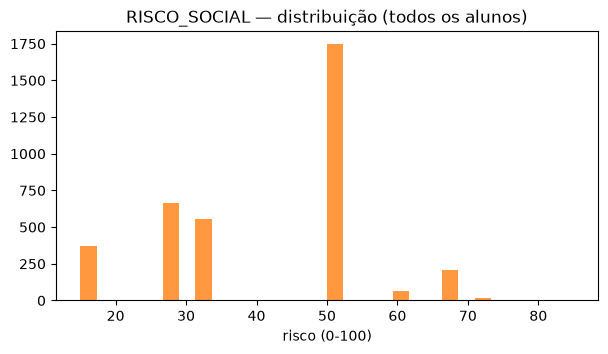

Target
Dropout     47.200328
Graduate    36.767391
Name: risco_social, dtype: float64

In [9]:
df["risco_social"] = social.compute(df)

fig, ax = plt.subplots()
ax.hist(df["risco_social"], bins=30, color="tab:orange", alpha=0.8)
ax.set_title("RISCO_SOCIAL — distribuição (todos os alunos)")
ax.set_xlabel("risco (0-100)")
plt.show()

df.groupby("Target")["risco_social"].mean()


## 4. SIN 3 — Bloco demográfico

Slide 8. Entradas: idade, `Displaced`, turno (diurno/noturno) e
`International`. Regras de exemplo:

- SE idade é alta E aluno é deslocado → risco alto
- SE idade é baixa E não é deslocado → risco baixo
- SE curso é noturno E idade é alta → risco médio


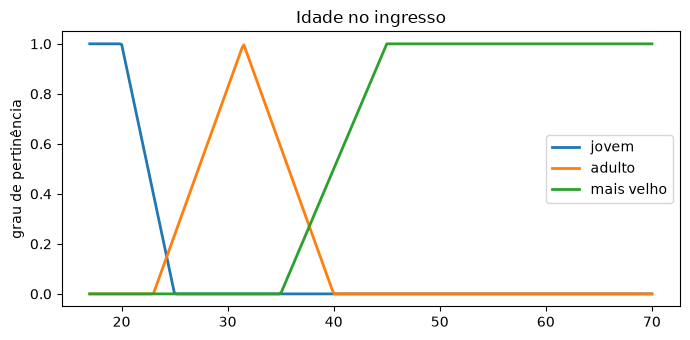

In [10]:
x_idade = np.linspace(17, 70, 300)
curves = demographic.fuzzify_idade(x_idade)
plot_membership(x_idade, curves, ["jovem", "adulto", "mais velho"], "Idade no ingresso")


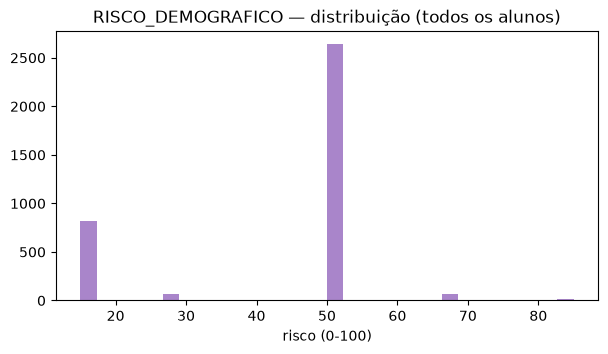

Target
Dropout     44.479759
Graduate    40.835215
Name: risco_demografico, dtype: float64

In [11]:
df["risco_demografico"] = demographic.compute(df)

fig, ax = plt.subplots()
ax.hist(df["risco_demografico"], bins=30, color="tab:purple", alpha=0.8)
ax.set_title("RISCO_DEMOGRAFICO — distribuição (todos os alunos)")
ax.set_xlabel("risco (0-100)")
plt.show()

df.groupby("Target")["risco_demografico"].mean()


## 5. SIN 4 — Sistema final (RISCO_EVASÃO)

Slide 9. Combina os 3 riscos intermediários (0-100). O bloco acadêmico tem
peso dominante nas regras:

- SE risco acadêmico é alto → evasão alta
- SE risco acadêmico médio E social alto → evasão alta
- SE todos são baixos → evasão baixa


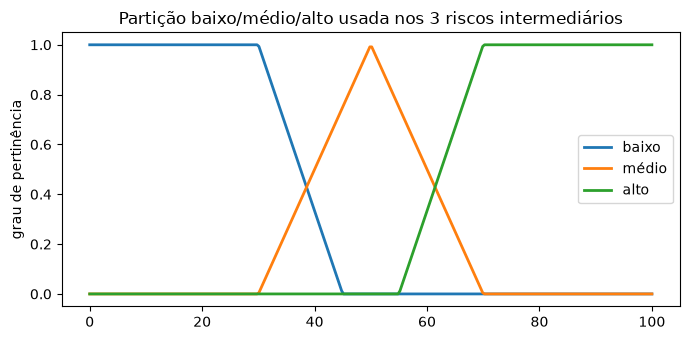

In [12]:
x_risco = np.linspace(0, 100, 300)
curves = final_block.fuzzify_risco(x_risco)
plot_membership(x_risco, curves, ["baixo", "médio", "alto"],
                 "Partição baixo/médio/alto usada nos 3 riscos intermediários")


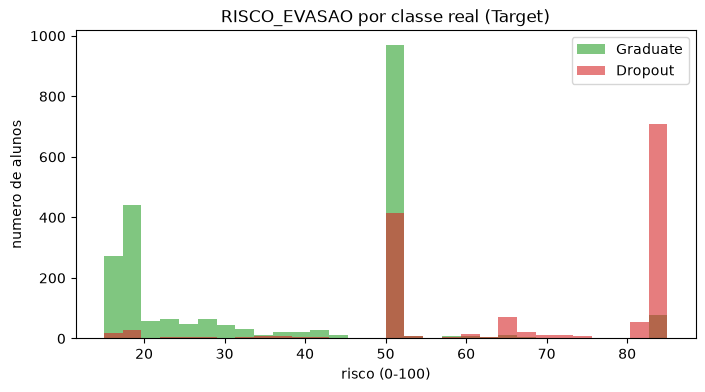

,risco_academico,risco_social,risco_demografico,risco_evasao
Target,,,,
Dropout,65.248252,47.200328,44.479759,68.714185
Graduate,37.732494,36.767391,40.835215,37.338397


In [13]:
df["risco_evasao"] = final_block.compute(
    df["risco_academico"].to_numpy(),
    df["risco_social"].to_numpy(),
    df["risco_demografico"].to_numpy(),
)

fig, ax = plt.subplots(figsize=(8, 4))
for label, color in [("Graduate", "tab:green"), ("Dropout", "tab:red")]:
    subset = df.loc[df["Target"] == label, "risco_evasao"]
    ax.hist(subset, bins=30, alpha=0.6, label=label, color=color)
ax.set_title("RISCO_EVASAO por classe real (Target)")
ax.set_xlabel("risco (0-100)")
ax.set_ylabel("numero de alunos")
ax.legend()
plt.show()

df.groupby("Target")[["risco_academico", "risco_social", "risco_demografico", "risco_evasao"]].mean()


## 6. Avaliação

Slide 10: risco ≥ limiar ⇒ previsto Dropout; caso contrário, Graduate.


In [14]:
THRESHOLD = 60

y_true = df["y_true"].to_numpy()
risco = df["risco_evasao"].to_numpy()

metrics = evaluate.metrics_at_threshold(y_true, risco, threshold=THRESHOLD)
pd.Series({k: v for k, v in metrics.items() if k != "confusion_matrix"}).to_frame("valor")


,valor
threshold,60.000000
accuracy,0.827548
precision_dropout,0.893954
recall_dropout,0.634764
f1_dropout,0.742387


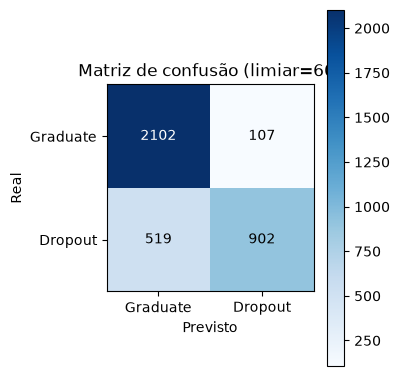

In [15]:
cm = np.array(metrics["confusion_matrix"])
fig, ax = plt.subplots(figsize=(4, 4))
im = ax.imshow(cm, cmap="Blues")
labels = ["Graduate", "Dropout"]
ax.set_xticks([0, 1]); ax.set_xticklabels(labels)
ax.set_yticks([0, 1]); ax.set_yticklabels(labels)
ax.set_xlabel("Previsto"); ax.set_ylabel("Real")
ax.set_title(f"Matriz de confusão (limiar={THRESHOLD})")
for i in range(2):
    for j in range(2):
        ax.text(j, i, str(cm[i][j]), ha="center", va="center",
                 color="white" if cm[i][j] > cm.max() / 2 else "black")
fig.colorbar(im)
fig.tight_layout()
plt.show()


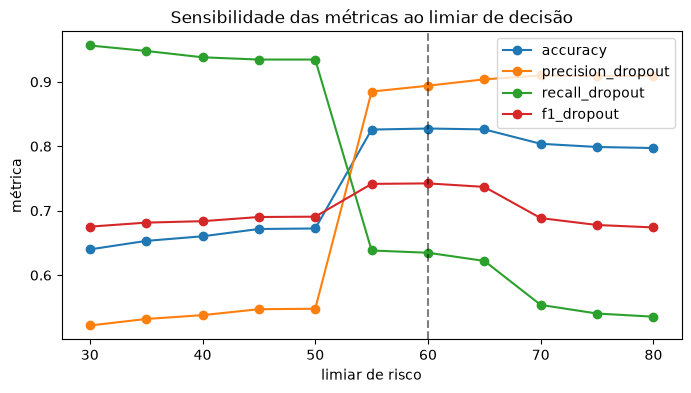

Melhor limiar por F1: 60 (F1=0.742, acuracia=0.828)


,threshold,accuracy,precision_dropout,recall_dropout,f1_dropout
0,30,0.639945,0.521889,0.956369,0.675280
1,35,0.653168,0.531991,0.947924,0.681508
2,40,0.660331,0.537934,0.938072,0.683765
3,45,0.671625,0.547178,0.934553,0.690229
4,50,0.672452,0.547855,0.934553,0.690767
5,55,0.825895,0.884878,0.638283,0.741619
6,60,0.827548,0.893954,0.634764,0.742387
7,65,0.826171,0.903885,0.622097,0.736974
8,70,0.803857,0.909827,0.553835,0.688539
9,75,0.798898,0.908876,0.540464,0.677846


In [16]:
sweep = evaluate.threshold_sweep(y_true, risco)
sweep_df = pd.DataFrame(sweep).drop(columns="confusion_matrix")

fig, ax = plt.subplots(figsize=(8, 4))
for col in ["accuracy", "precision_dropout", "recall_dropout", "f1_dropout"]:
    ax.plot(sweep_df["threshold"], sweep_df[col], marker="o", label=col)
ax.axvline(THRESHOLD, color="black", linestyle="--", alpha=0.5)
ax.set_xlabel("limiar de risco")
ax.set_ylabel("métrica")
ax.set_title("Sensibilidade das métricas ao limiar de decisão")
ax.legend()
plt.show()

best = evaluate.best_threshold(sweep)
print(f"Melhor limiar por F1: {best['threshold']} (F1={best['f1_dropout']:.3f}, acuracia={best['accuracy']:.3f})")
sweep_df


## 7. Conclusão

- O sistema fuzzy recupera bem o sinal de evasão **sem nunca ver o
  `Target`** diretamente — as regras são inteiramente baseadas em
  conhecimento de domínio (slides 6-9).
- O risco médio por classe confirma a coerência: alunos que evadiram têm
  risco previsto muito maior em todos os blocos, principalmente no
  acadêmico.
- A distribuição de `RISCO_EVASAO` mostra boa separação nos extremos
  (~15-20 vs ~85), com uma faixa de sobreposição em torno de 50 — os casos
  "cinzentos" que a saída contínua expressa melhor que uma classe rígida
  (ideia central do slide 11).
- **Próximos passos** (slide 12): ajustar faixas/regras a partir da matriz
  de confusão (reduzir falsos negativos) e discutir os casos de
  sobreposição em detalhe.


In [17]:
df[["risco_academico", "risco_social", "risco_demografico", "risco_evasao", "Target"]].to_csv(
    "outputs/predictions_notebook.csv", index=False)
print("Salvo em outputs/predictions_notebook.csv")


Salvo em outputs/predictions_notebook.csv
